In [9]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\ahmed\Desktop\my project\NetSentry_Final_Ready.csv")
df.head(10)

,transact,API call signature,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,S
6,0,0,1,1,0,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,0,S
8,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,S
9,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,1,0,0,0,0,S


In [7]:
import pandas as pd

# 1. قراءة الملف
df = pd.read_csv(r"C:\Users\ahmed\Desktop\my project\NetSentry_Final_Ready.csv")

# 2. استخراج الميزات - لاحظ استخدام columns بالجمع
features_list = df.columns.tolist()

# 3. طباعة العدد الإجمالي
print(f"Total features: {len(features_list)}")
print("-" * 20)

# 4. حلقة التكرار (تأكد أن الاسم مطابق تماماً للمتغير فوق)
for i, feature in enumerate(features_list):
    print(f"{i+1}. {feature}")

Total features: 217
--------------------
1. transact
2. API call signature
3. onServiceConnected
4. bindService
5. attachInterface
6. ServiceConnection
7. android.os.Binder
8. SEND_SMS
9. Ljava.lang.Class.getCanonicalName
10. Ljava.lang.Class.getMethods
11. Ljava.lang.Class.cast
12. Ljava.net.URLDecoder
13. android.content.pm.Signature
14. android.telephony.SmsManager
15. READ_PHONE_STATE
16. getBinder
17. ClassLoader
18. Landroid.content.Context.registerReceiver
19. Ljava.lang.Class.getField
20. Landroid.content.Context.unregisterReceiver
21. GET_ACCOUNTS
22. RECEIVE_SMS
23. Ljava.lang.Class.getDeclaredField
24. READ_SMS
25. getCallingUid
26. Ljavax.crypto.spec.SecretKeySpec
27. android.intent.action.BOOT_COMPLETED
28. USE_CREDENTIALS
29. MANAGE_ACCOUNTS
30. android.content.pm.PackageInfo
31. KeySpec
32. TelephonyManager.getLine1Number
33. DexClassLoader
34. HttpGet.init
35. SecretKey
36. Ljava.lang.Class.getMethod
37. System.loadLibrary
38. android.intent.action.SEND
39. Ljavax.crypt

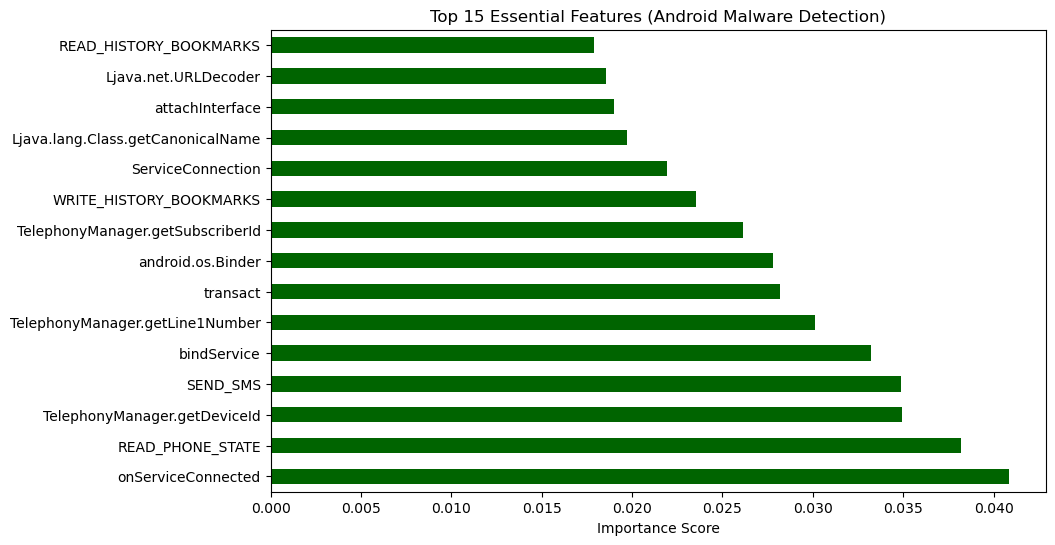

In [8]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. تجهيز البيانات (افترضنا أن العمود الأخير هو 'class' أو 'label')
X = df.drop(df.columns[-1], axis=1) 
y = df[df.columns[-1]]

# 2. تدريب نموذج سريع لمعرفة الأهمية
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. استخراج أهم 15 ميزة جوهرية
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(15).plot(kind='barh', color='darkgreen')
plt.title("Top 15 Essential Features (Android Malware Detection)")
plt.xlabel("Importance Score")
plt.show()

In [10]:
df.shape

(7261, 217)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7261 entries, 0 to 7260
Columns: 217 entries, transact to class
dtypes: int64(216), object(1)
memory usage: 12.0+ MB
